# **Phenotypic Bias in Heart Disease Prediction**
### *Fairness and Explainability Analysis using the UCI Heart Disease Dataset (Cleveland)*

**Author:** Francisca Mihalache  
**Course:** Artificial Intelligence and Society — Individual Assignment 


### **Objective**
This notebook explores potential *phenotypic bias* in heart disease prediction models by analyzing whether performance differs across chest pain types (`cp`) — *typical angina*, *atypical angina*, *non-anginal pain*, and *asymptomatic* — in the **UCI Heart Disease (Cleveland)** dataset.  

The study integrates two key Responsible AI dimensions:  
- **Fairness:** evaluating performance disparities between clinical subgroups.  
- **Explainability:** using SHAP values to understand which features contribute to those differences.  

Results are discussed from both a **technical** and **ethical** standpoint, reflecting on possible subdiagnosis risks for patients with less typical symptoms.


###  Table of Contents

1. [Background and Dataset Description](#1)
2. [Dataset Loading and Structure](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Preprocessing](#4)
5. [Model Training](#5)
6. [Fairness Analysis by Chest Pain Type](#6)
7. [Explainability Analysis (SHAP)](#7)
8. [Ethical Reflection and Discussion](#8)
9. [Conclusions](#9)
10. [References](#10)





#### Environment Setup


In [1]:
pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


#### Imports

In [ ]:
from ucimlrepo import fetch_ucirepo 
import seaborn as sns
import matplotlib.pyplot as plt

<a id="1"></a>
## 1. Background and Dataset Description


#### Dataset Loading and Description
We fetch the UCI Heart Disease (Cleveland) dataset using the ucimlrepo package.
The dataset includes 303 patients and 13 clinical features related to cardiovascular risk.

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Fetch dataset
heart_disease = fetch_ucirepo(id=45)

# Data as pandas DataFrames
X = heart_disease.data.features
y = heart_disease.data.targets

# Display concise metadata
meta_df = pd.DataFrame(list(heart_disease.metadata.items()), columns=["Key", "Value"])
display(meta_df)  

# Display only first 10 variable descriptions
display(heart_disease.variables)

,Key,Value
0,uci_id,45
1,name,Heart Disease
2,repository_url,https://archive.ics.uci.edu/dataset/45/heart+d...
3,data_url,https://archive.ics.uci.edu/static/public/45/d...
4,abstract,"4 databases: Cleveland, Hungary, Switzerland, ..."
5,area,Health and Medicine
6,tasks,[Classification]
7,characteristics,[Multivariate]
8,num_instances,303
9,num_features,13


,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,years,no
1,sex,Feature,Categorical,Sex,None,None,no
2,cp,Feature,Categorical,None,None,None,no
3,trestbps,Feature,Integer,None,resting blood pressure (on admission to the ho...,mm Hg,no
4,chol,Feature,Integer,None,serum cholestoral,mg/dl,no
5,fbs,Feature,Categorical,None,fasting blood sugar > 120 mg/dl,None,no
6,restecg,Feature,Categorical,None,None,None,no
7,thalach,Feature,Integer,None,maximum heart rate achieved,None,no
8,exang,Feature,Categorical,None,exercise induced angina,None,no
9,oldpeak,Feature,Integer,None,ST depression induced by exercise relative to ...,None,no


The tables above summarize the **dataset metadata** and the **full list of variables** retrieved from the UCI Machine Learning Repository.  
The original code example from the `ucimlrepo` documentation was slightly modified to present the information in a more compact and structured way.

From the **metadata table**, we confirm that:

- **Task type:** Classification (predicting presence of heart disease)  
- **Instances:** 303 patients  
- **Features:** 13 clinical attributes (a mix of categorical, integer, and real types)  
- **Demographic variables:** Age and Sex  
- **Target variable:** `num` — ranges from 0 (no disease) to 4 (presence of disease)  
- **Missing values:** Yes — represented as `NaN`  
- **Dataset creation year:** 1989, updated in 2023  
- **Creators:** Andras Janosi, William Steinbrunn, Matthias Pfisterer, Robert Detrano  
- **DOI:** [10.24432/C52P4X](https://doi.org/10.24432/C52P4X)  
- **Repository link:** [UCI Heart Disease Dataset](https://archive.ics.uci.edu/dataset/45/heart+disease)

From the **variable table**, we can summarize:
- There are 13 input features (`age`, `sex`, `cp`, `trestbps`, `chol`, `fbs`, `restecg`, `thalach`, `exang`, `oldpeak`, `slope`, `ca`, `thal`) and 1 target variable (`num`).  
- Most features are either **integer** or **categorical**, aligning with clinical measurements and diagnostic categories.  
- The `cp` (chest pain type) variable is especially important for this project — it differentiates patients by pain presentation (*typical angina*, *atypical angina*, *non-anginal pain*, *asymptomatic*) and will be used to study *phenotypic bias*.  
- The variables `ca` (number of major vessels) and `thal` contain missing values.  
- Descriptive units include `mm Hg` (for blood pressure) and `mg/dl` (for cholesterol).  

This metadata inspection confirms that the dataset is well-suited for the intended analysis on **fairness** and **explainability**.  

Next, we proceed to **data preprocessing**, where the target variable will be binarized and missing values will be handled before training the classification models.


### Variable Definitions

According to the official documentation provided by the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/45/heart+disease), the Heart Disease (Cleveland) dataset includes **14 clinical attributes** originally described by *Detrano et al. (1989)* in the *American Journal of Cardiology*.  

The variable definitions are summarized below and will be considered throughout this study for proper interpretation and clinical consistency.

| Feature | Description | Type / Units | Encoded Values |
|----------|--------------|---------------|----------------|
| **age** | Age of the patient | Integer / years | — |
| **sex** | Biological sex | Categorical | 1 = male, 0 = female |
| **cp** | Chest pain type | Categorical | 1 = typical angina<br>2 = atypical angina<br>3 = non-anginal pain<br>4 = asymptomatic |
| **trestbps** | Resting blood pressure (on hospital admission) | Integer / mm Hg | — |
| **chol** | Serum cholesterol level | Integer / mg/dl | — |
| **fbs** | Fasting blood sugar > 120 mg/dl | Categorical | 1 = true, 0 = false |
| **restecg** | Resting electrocardiographic results | Categorical | 0 = normal<br>1 = ST–T abnormality<br>2 = left ventricular hypertrophy |
| **thalach** | Maximum heart rate achieved | Integer / bpm | — |
| **exang** | Exercise-induced angina | Categorical | 1 = yes, 0 = no |
| **oldpeak** | ST depression induced by exercise relative to rest | Float | — |
| **slope** | Slope of the peak exercise ST segment | Categorical | 1 = upsloping<br>2 = flat<br>3 = downsloping |
| **ca** | Number of major vessels colored by fluoroscopy | Integer (0–3) | — |
| **thal** | Thalassemia | Categorical | 3 = normal<br>6 = fixed defect<br>7 = reversible defect |
| **num** | Diagnosis of heart disease (angiographic disease status) | Target variable | 0 = no disease (< 50 % narrowing)<br>1–4 = disease present (> 50 % narrowing) |

These definitions form the foundation of all subsequent analyses.  
They ensure that feature interpretations and clinical reasoning remain consistent with the original dataset documentation and medical context.


## Exploratory Data Analysis (EDA)

After loading and describing the dataset, we now explore its main statistical properties and internal patterns to better understand how the features are distributed.

In [3]:
# General information
X.info()

# Quick view of numeric variables
X.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


The dataset consists of **303 patient records** and **13 measurable features** related to cardiovascular health.  
All variables are numeric, meaning that categorical features (such as `sex`, `cp`, `restecg`, and `slope`) are encoded as integers.  
This numeric representation simplifies model training but requires semantic remapping later for clearer interpretation.  

Two variables, `ca` (number of major vessels) and `thal` (thalassemia type), contain a small number of missing values.  
These missing entries will be imputed before training to ensure data consistency.  

At this point, the dataset appears well-structured and suitable for the upcoming analyses.  
The next steps will focus on exploring distributions, feature relationships, and possible data imbalances that may affect fairness across patient subgroups.


#### Missing Values

In [4]:
# Check for missing data
missing_summary = X.isna().sum()
missing_summary[missing_summary > 0]


ca      4
thal    2
dtype: int64

As confirmed earlier in the variable table, only two features contain missing values: `ca` (number of major vessels) with **4 missing entries**, and `thal` (thalassemia type) with **2 missing entries**.  The number of missing values is very small compared to the dataset size, so these can be safely imputed later without affecting the statistical integrity of the data.


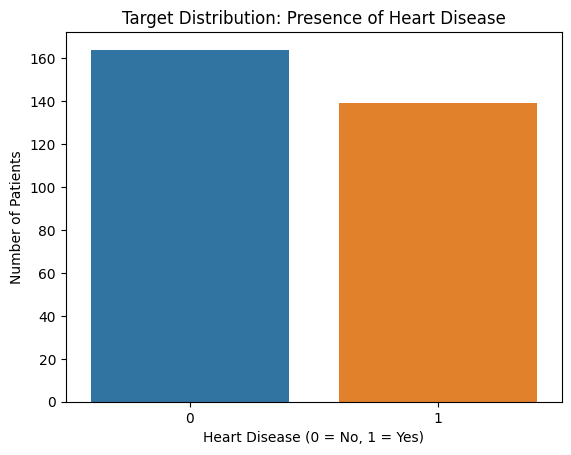

In [6]:
sns.countplot(x=y['num'].apply(lambda v: 1 if v > 0 else 0))
plt.title('Target Distribution: Presence of Heart Disease')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.show()
